# 04 — The visual pass: the objects, drawn

*Written after the assessor required that the method's own discovery order be restored — look at the distribution of ones and zeros first, and let the table headers, the formulae and the statistics follow from what was seen.*

In [1]:
"""Path setup: makes the notebook runnable from anywhere."""
import os, sys, json, warnings
warnings.filterwarnings("ignore")

here = os.path.abspath(os.getcwd())
while here != "/" and not os.path.exists(os.path.join(here, "PROTOCOL_causal_timeseries.md")):
    here = os.path.dirname(here)
if here == "/":
    here = os.path.expanduser("~/Documents/projects/CausalBool/imp-prices")
ROOT = here
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "scripts"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
print("root:", ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

root: /Users/alberto/Documents/projects/CausalBool/imp-prices
numpy 2.2.6 | pandas 2.3.3 | matplotlib 3.11.1


## 1. Why this notebook exists, and why it comes first

The index-set method was not discovered by writing down formulae. It was
discovered by looking at the distribution of ones and zeros, seeing a pattern in
it, and only then asking what table headers would express that pattern; the
behaviour formulae came after the headers, the formal equations after the
formulae, and the statistics arrived last, as justification for something already
seen. Exactness and speed were consequences of that order, not of the algebra.

Phases 1 and 2 of this package ran that order **backwards**. We binarised the
regimes and immediately scored gates against a null. The binary matrix that the
whole method eats has never been rendered. One figure existed in `figures/` for
the entire project before this notebook, and it belongs to the Phase 3 opening.

That is a Gate 1 failure sitting underneath every number in Phases 1 and 2. It
does not by itself make those numbers wrong — several were checked hard, and two
were withdrawn on audit — but it does mean **no one has seen the object they are
about**. This notebook is the missing look, and it deliberately measures nothing
until section 5.

**Reading rule for this notebook.** Sections 2 to 4 contain no statistics on
purpose. If a pattern is real it should be visible; if it is only visible after
being averaged, that is a fact about the averaging.

## 2. The raw series, at full length

panel: (199, 7) | 2010-01-31 -> 2026-07-31
train rows: 139  test rows: 30


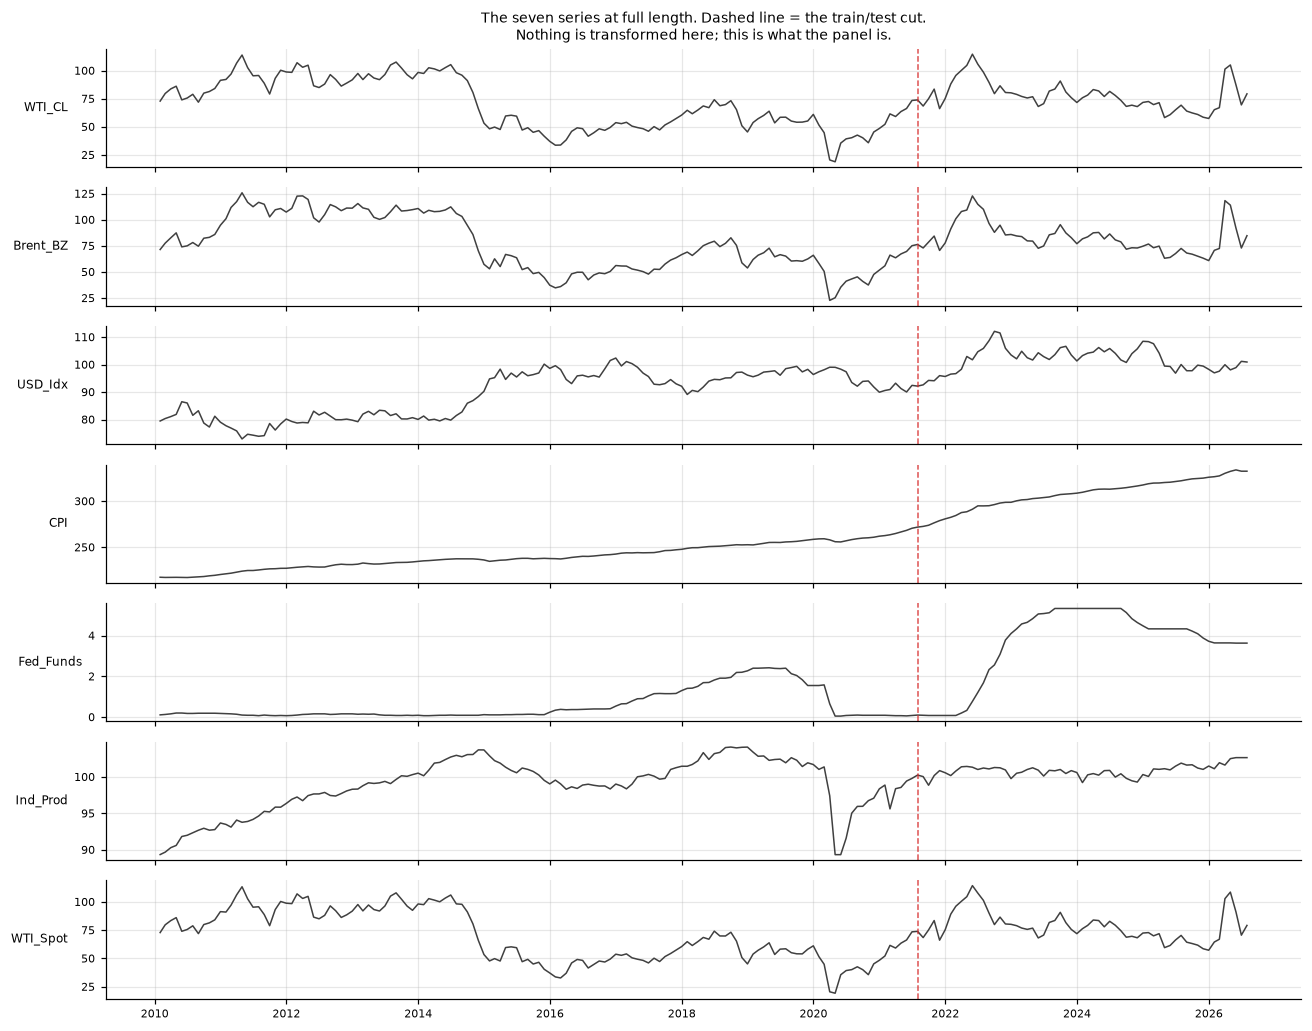

In [2]:
from imp_prices import load_and_split, RegimeDiscretiser, SERIES, TARGET

split = load_and_split()
full = split.full
print("panel:", full.shape, "|", full.index[0].date(), "->", full.index[-1].date())
print("train rows:", len(split.train), " test rows:", len(split.test))

fig, axes = plt.subplots(len(full.columns), 1, figsize=(12, 1.35 * len(full.columns)),
                         sharex=True)
for ax, col in zip(axes, full.columns):
    ax.plot(full.index, full[col], lw=1.0, color="0.25")
    ax.axvline(split.train.index[-1], color="#D62728", lw=1.0, ls="--", alpha=0.8)
    ax.set_ylabel(col, fontsize=8, rotation=0, ha="right", va="center")
    ax.tick_params(labelsize=7)
axes[0].set_title("The seven series at full length. Dashed line = the train/test cut.\n"
                  "Nothing is transformed here; this is what the panel is.", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_A1_raw_series.png"),
                                dpi=130, bbox_inches="tight")
plt.show()

## 3. The ternary object — regimes as a colour band

The HMM turns each series into a three-state sequence. Before asking whether one
series predicts another, look at what the sequences *are*: how long the states
last, whether the series switch together, whether the panel has visible common
episodes.

Model is not converging.  Current: 133.6292135815284 is not greater than 133.64611090460522. Delta is -0.016897323076818793


Model is not converging.  Current: 135.12412379396633 is not greater than 135.13466135759776. Delta is -0.010537563631430658


Model is not converging.  Current: 137.95241214051376 is not greater than 137.9719991672316. Delta is -0.019587026717829303


Model is not converging.  Current: 133.8785930254865 is not greater than 133.88411470889034. Delta is -0.0055216834038276374


Model is not converging.  Current: 137.8805787609427 is not greater than 137.88701219673231. Delta is -0.0064334357896029815


...

Model is not converging.  Current: 134.6463798744827 is not greater than 134.6661180024403. Delta is -0.019738127957594997


Model is not converging.  Current: 138.689566784798 is not greater than 138.75651219277114. Delta is -0.06694540797315085


Model is not converging.  Current: 137.73058048980627 is not greater than 137.74346014343874. Delta is -0.012879653632467125


Model is not converging.  Current: 137.0533835102066 is not greater than 137.05519354805233. Delta is -0.0018100378457290844


regime frame: (198, 7)
               0      1      2
WTI_CL     0.162  0.636  0.202
Brent_BZ   0.101  0.652  0.247
USD_Idx    0.884    NaN  0.116
CPI        1.000    NaN    NaN
Fed_Funds  0.010  0.505  0.485
Ind_Prod   0.030    NaN  0.970
WTI_Spot   0.207  0.667  0.126


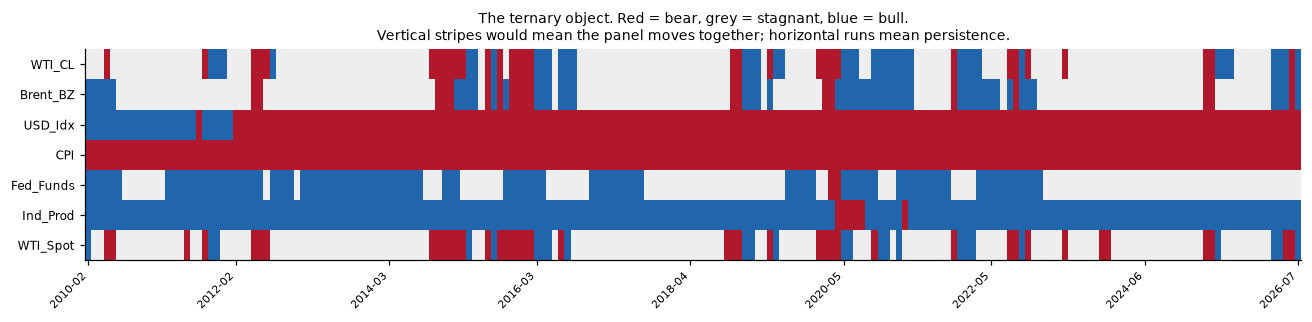

In [3]:
disc = RegimeDiscretiser("gaussian").fit(split.train)
reg = disc.transform(full)
print("regime frame:", reg.shape)
print(reg.apply(lambda s: s.value_counts(normalize=True)).round(3).T)

import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(["#B2182B", "#EEEEEE", "#2166AC"])  # bear, stagnant, bull

fig, ax = plt.subplots(figsize=(12, 3.0))
ax.imshow(reg.T.to_numpy(), aspect="auto", cmap=cmap, vmin=0, vmax=2,
          interpolation="nearest")
ax.set_yticks(range(reg.shape[1])); ax.set_yticklabels(reg.columns, fontsize=8)
ticks = np.linspace(0, len(reg) - 1, 9).astype(int)
ax.set_xticks(ticks); ax.set_xticklabels([reg.index[t].strftime("%Y-%m") for t in ticks],
                                         fontsize=7, rotation=45, ha="right")
ax.grid(False)
ax.set_title("The ternary object. Red = bear, grey = stagnant, blue = bull.\n"
             "Vertical stripes would mean the panel moves together; horizontal runs "
             "mean persistence.", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_A2_regime_band.png"),
                                dpi=130, bbox_inches="tight")
plt.show()

## 4. The binary object — the thing the method actually eats

This is the render that should have existed before any Phase 1 number. Each
series becomes two bits, so the panel becomes a matrix of ones and zeros. All
three encodings are drawn, because the encoding is a choice and its consequences
should be *visible* rather than argued about.

thermometer  198 rows x 14 nodes | mean density 0.482
binary       198 rows x 14 nodes | mean density 0.329
onehot       198 rows x 21 nodes | mean density 0.333


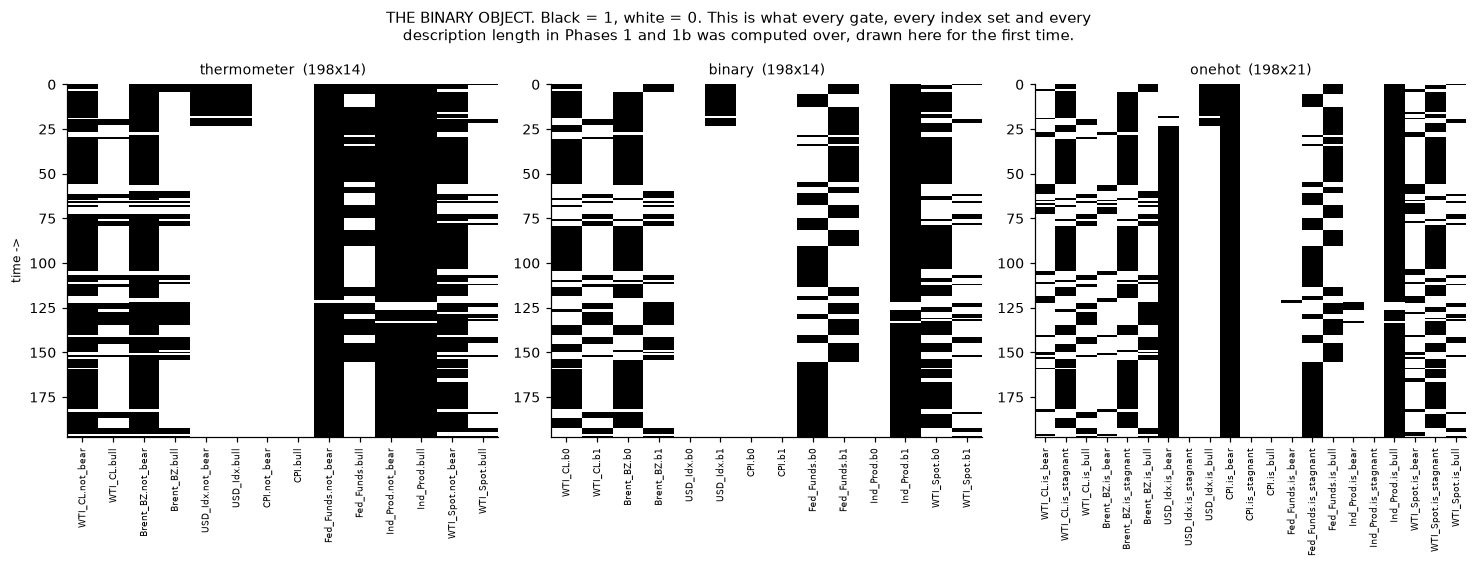

In [4]:
from imp_prices.binarise import encode_frame, WIDTH, SUFFIX

encs = {k: encode_frame(reg, k) for k in ("thermometer", "binary", "onehot")}
for k, Bk in encs.items():
    print(f"{k:<12s} {Bk.shape[0]} rows x {Bk.shape[1]} nodes | "
          f"mean density {Bk.to_numpy().mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.2))
for ax, (k, Bk) in zip(axes, encs.items()):
    ax.imshow(Bk.to_numpy(), aspect="auto", cmap="binary", vmin=0, vmax=1,
              interpolation="nearest")
    ax.set_xticks(range(Bk.shape[1]))
    ax.set_xticklabels(Bk.columns, fontsize=6, rotation=90)
    ax.set_title(f"{k}  ({Bk.shape[0]}x{Bk.shape[1]})", fontsize=9)
    ax.grid(False)
axes[0].set_ylabel("time ->", fontsize=8)
fig.suptitle("THE BINARY OBJECT. Black = 1, white = 0. This is what every gate, every "
             "index set and every\ndescription length in Phases 1 and 1b was computed "
             "over, drawn here for the first time.", fontsize=9.5)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_A3_binary_object.png"),
                                dpi=130, bbox_inches="tight")
plt.show()

### 4b. The same object with the columns grouped

Column order in the render above is the panel's order, which is arbitrary. If
there is block structure, an ordering that puts similar columns together will
show it, and one that does not will not. Both are shown so that the reordering
cannot manufacture the pattern.

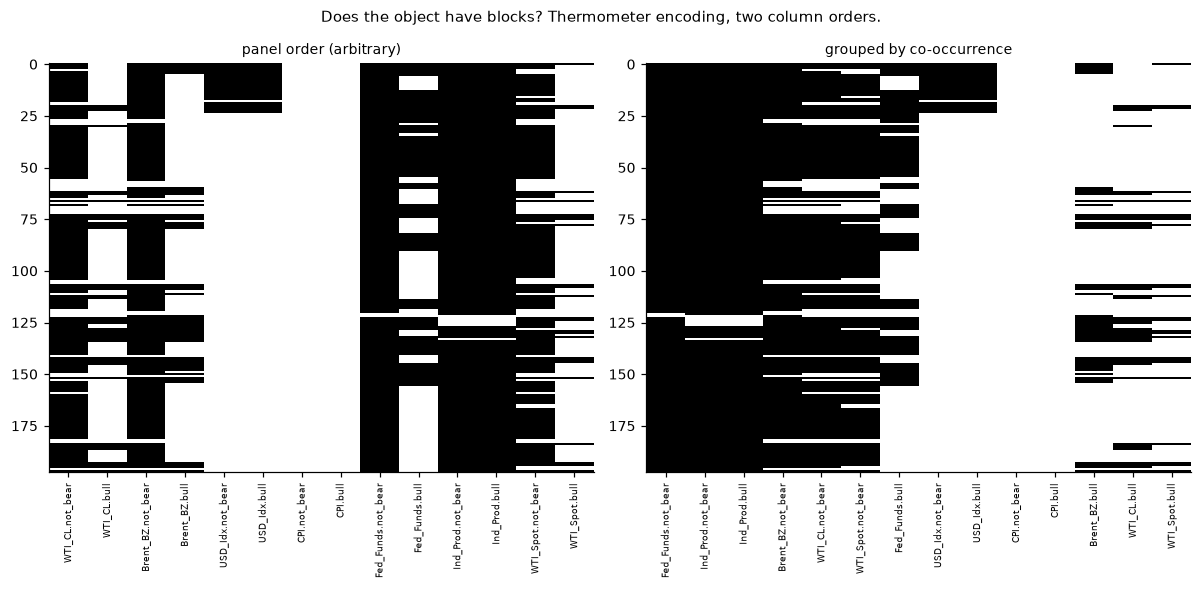

grouped order: ['Fed_Funds.not_bear', 'Ind_Prod.not_bear', 'Ind_Prod.bull', 'Brent_BZ.not_bear', 'WTI_CL.not_bear', 'WTI_Spot.not_bear', 'Fed_Funds.bull', 'USD_Idx.not_bear', 'USD_Idx.bull', 'CPI.not_bear', 'CPI.bull', 'Brent_BZ.bull', 'WTI_CL.bull', 'WTI_Spot.bull']


In [5]:
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import pdist

B = encs["thermometer"]
M = B.to_numpy().astype(float)
# Order columns by similarity of their bit sequences (Hamming), which is a
# statement about co-occurrence in time and nothing else.
order = leaves_list(linkage(pdist(M.T, metric="hamming"), method="average"))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
for ax, (cols, ttl) in zip(axes, [(list(range(M.shape[1])), "panel order (arbitrary)"),
                                  (list(order), "grouped by co-occurrence")]):
    ax.imshow(M[:, cols], aspect="auto", cmap="binary", vmin=0, vmax=1,
              interpolation="nearest")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([B.columns[c] for c in cols], fontsize=6, rotation=90)
    ax.set_title(ttl, fontsize=9); ax.grid(False)
fig.suptitle("Does the object have blocks? Thermometer encoding, two column orders.",
             fontsize=9.5)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_A4_column_order.png"),
                                dpi=130, bbox_inches="tight")
plt.show()
print("grouped order:", [B.columns[c] for c in order])

## 5. Now measure — but only what the pictures asked for

Two things dominate the renders above: the runs, and which corners of the
hypercube the data ever visits. Both are properties of the object rather than
summaries imposed on it.

### 5a. Run lengths — persistence made visible

Inherited anchor A11 puts one-month regime persistence at 79.31 per cent, and
that number is the bar Phase 1 failed to beat. A single percentage cannot say
whether persistence comes from a few long episodes or many short ones, and those
two worlds have very different effective sample sizes.

The effective row count is the number of RUNS, not the number of months.
              node  n_runs  longest  median_run
   WTI_CL.not_bear      33       32         3.0
       WTI_CL.bull      30       31         3.0
 Brent_BZ.not_bear      23       32         2.0
     Brent_BZ.bull      27       55         3.0
  USD_Idx.not_bear       4      174        11.5
      USD_Idx.bull       4      174        11.5
      CPI.not_bear       1      198       198.0
          CPI.bull       1      198       198.0
Fed_Funds.not_bear       3      121        75.0
    Fed_Funds.bull      22       42         6.5
 Ind_Prod.not_bear       5      122         6.0
     Ind_Prod.bull       5      122         6.0
 WTI_Spot.not_bear      39       26         3.0
     WTI_Spot.bull      31       40         2.0

nominal rows: 198   median runs across nodes: 14


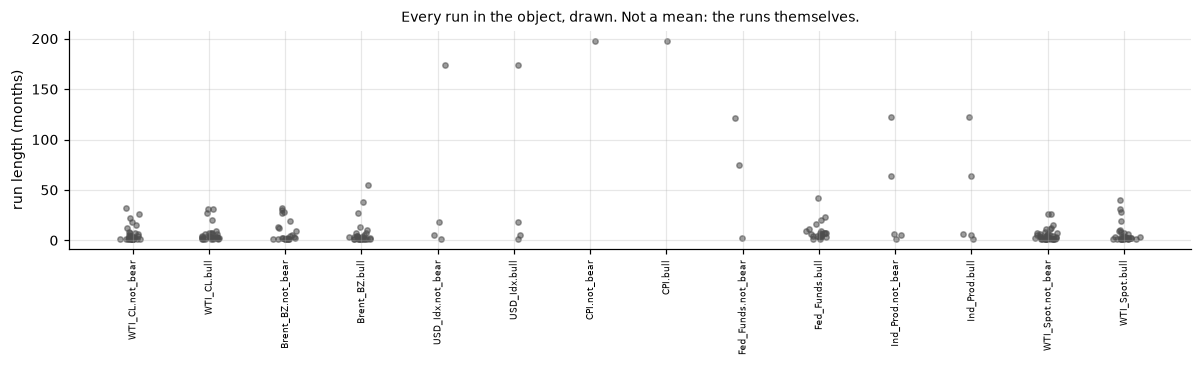

In [6]:
def runs(v):
    v = np.asarray(v); out, n = [], 1
    for a, b in zip(v, v[1:]):
        if a == b: n += 1
        else: out.append(n); n = 1
    out.append(n); return np.array(out)

rows = []
for col in B.columns:
    r = runs(B[col].to_numpy())
    rows.append({"node": col, "n_runs": len(r), "longest": int(r.max()),
                 "median_run": float(np.median(r))})
runtab = pd.DataFrame(rows)
print("The effective row count is the number of RUNS, not the number of months.")
print(runtab.to_string(index=False))
print(f"\nnominal rows: {len(B)}   median runs across nodes: "
      f"{runtab['n_runs'].median():.0f}")

fig, ax = plt.subplots(figsize=(11, 3.4))
rng = np.random.default_rng(0)
for i, col in enumerate(B.columns):
    r = runs(B[col].to_numpy())
    ax.scatter(np.full(len(r), i) + rng.normal(0, 0.07, len(r)),
               r, s=12, alpha=0.55, color="0.3")
ax.set_xticks(range(len(B.columns)))
ax.set_xticklabels(B.columns, fontsize=6, rotation=90)
ax.set_ylabel("run length (months)")
ax.set_title("Every run in the object, drawn. Not a mean: the runs themselves.",
             fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_B1_runs.png"),
                                dpi=130, bbox_inches="tight")
plt.show()

### 5b. The support — which corners of the hypercube are ever visited

**This is the step the whole programme turns on.** An index set is precisely the
set of input patterns that map to an output of one. Phases 1 and 1b fitted gates
without ever asking which input patterns the data *contains*. If the panel only
ever visits four of the eight corners of a three-input cube, then most of the
gate catalogue is indistinguishable on this data, and a "best gate" is a choice
made by the unvisited corners — that is, by nothing.

In [7]:
from itertools import combinations

def support(frame, cols):
    """Occupancy of the 2^k input patterns for a set of columns."""
    Mx = frame[list(cols)].to_numpy()
    k = len(cols)
    codes = Mx @ (1 << np.arange(k))
    return np.bincount(codes, minlength=1 << k)

k = 3
occ = []
for cols in combinations(list(B.columns), k):
    cnt = support(B, cols)
    occ.append({"cols": " + ".join(c.split(".")[0][:8] for c in cols),
                "visited": int((cnt > 0).sum()), "of": 1 << k,
                "top_share": float(cnt.max() / cnt.sum())})
occ = pd.DataFrame(occ).sort_values("visited")
print(f"Over all {len(occ)} triples of nodes, corners of the {1<<k}-corner cube "
      f"actually visited:")
print(occ["visited"].value_counts().sort_index().to_string())
print(f"\nmedian corners visited: {occ['visited'].median():.0f} of {1<<k}")
print(f"median share of rows in the single most common corner: "
      f"{occ['top_share'].median():.3f}")
print("\nLeast-covered triples:"); print(occ.head(6).to_string(index=False))

Over all 364 triples of nodes, corners of the 8-corner cube actually visited:
visited
2     16
3     60
4    103
5     69
6     78
7     27
8     11

median corners visited: 5 of 8
median share of rows in the single most common corner: 0.697

Least-covered triples:
                   cols  visited  of  top_share
   CPI + CPI + Ind_Prod        2   8   0.969697
    USD_Idx + CPI + CPI        2   8   0.883838
USD_Idx + USD_Idx + CPI        2   8   0.883838
USD_Idx + USD_Idx + CPI        2   8   0.883838
   Brent_BZ + CPI + CPI        2   8   0.752525
   CPI + CPI + WTI_Spot        2   8   0.873737


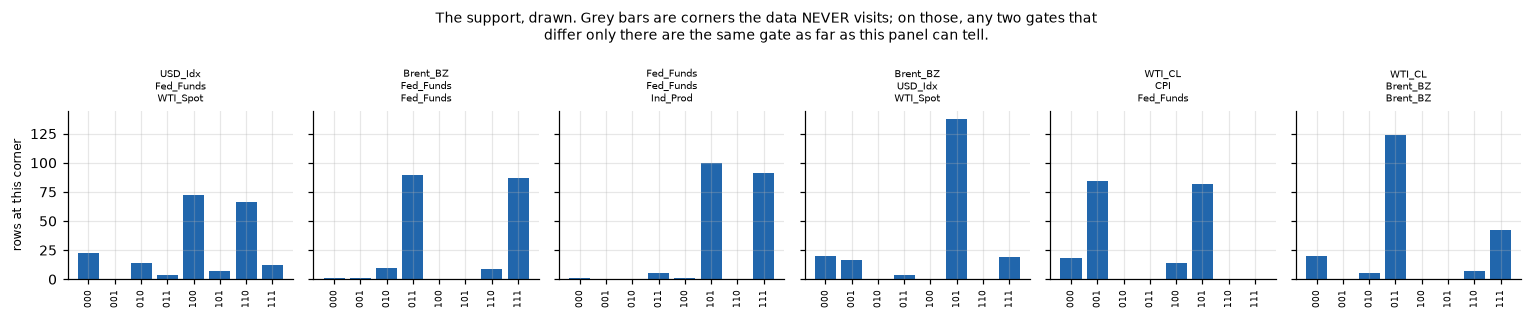

In [8]:
# Draw the support for a few triples rather than reporting only its size.
picks = list(combinations(list(B.columns), 3))
rng = np.random.default_rng(1)
chosen = [picks[i] for i in rng.choice(len(picks), 6, replace=False)]

fig, axes = plt.subplots(1, 6, figsize=(14, 2.9), sharey=True)
for ax, cols in zip(axes, chosen):
    cnt = support(B, cols)
    ax.bar(range(len(cnt)), cnt,
           color=["#CCCCCC" if c == 0 else "#2166AC" for c in cnt])
    ax.set_xticks(range(len(cnt)))
    ax.set_xticklabels([format(i, "03b") for i in range(len(cnt))],
                       fontsize=6, rotation=90)
    ax.set_title("\n".join(c.split(".")[0][:9] for c in cols), fontsize=6.5)
axes[0].set_ylabel("rows at this corner", fontsize=8)
fig.suptitle("The support, drawn. Grey bars are corners the data NEVER visits; on those, "
             "any two gates that\ndiffer only there are the same gate as far as this "
             "panel can tell.", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_B2_support.png"),
                                dpi=130, bbox_inches="tight")
plt.show()

## 6. The dead columns, and a number that did not survive its own reference

The regime band in section 3 shows CPI as a single unbroken bar and USD_Idx as one
switch followed by six years of nothing. That is visible before any statistic, so
the statistic that follows is a measurement of something already seen rather than
a search for something to say.

Two questions have to be separated, because they have different cures: is a
column dead because **the series has no regimes**, or because **the fit
degenerated**? Twenty-nine non-convergence warnings fired during section 3.

In [9]:
lr = np.log(full).diff().dropna()
print("Log-return dispersion by series — the input the HMM sees:")
for c in full.columns:
    v = lr[c].to_numpy()
    print(f"   {c:<10s} sd={v.std():.5f}  min={v.min():+.5f}  max={v.max():+.5f}")

print("\nRegime occupancy (3-state fit). An empty middle state means the fit "
      "collapsed to two:")
for c in reg.columns:
    print(f"   {c:<10s} {np.bincount(reg[c].to_numpy(), minlength=3)}")

Log-return dispersion by series — the input the HMM sees:
   WTI_CL     sd=0.11726  min=-0.78187  max=+0.63327
   Brent_BZ   sd=0.11010  min=-0.79824  max=+0.49034
   USD_Idx    sd=0.02064  min=-0.05535  max=+0.05792
   CPI        sd=0.00264  min=-0.00795  max=+0.01248
   Fed_Funds  sd=0.24954  min=-2.56495  max=+0.91629
   Ind_Prod   sd=0.00957  min=-0.08655  max=+0.03679
   WTI_Spot   sd=0.11757  min=-0.78196  max=+0.61503

Regime occupancy (3-state fit). An empty middle state means the fit collapsed to two:
   WTI_CL     [ 32 126  40]
   Brent_BZ   [ 20 129  49]
   USD_Idx    [175   0  23]
   CPI        [198   0   0]
   Fed_Funds  [  2 100  96]
   Ind_Prod   [  6   0 192]
   WTI_Spot   [ 41 132  25]


CPI's log returns have a dispersion roughly forty times smaller than WTI's, and
the three-state fit puts every one of its months in one state. The middle state
is empty for three of the seven series, so for those the three-state model is a
two-state model wearing a third label. This is a property of the panel, not of
the evaluation window: it holds inside the training rows on their own.

### 6b. The number I nearly reported, and why it is withdrawn

Counting nodes that never change across the test window gives a striking figure.
Before it goes anywhere near a claim, it needs a reference: a node with four runs
in 198 months will often be constant across any 30-month window simply because
its runs are long. The reference below shifts each column circularly, which
preserves that column's own run structure exactly and randomises only where the
test window lands.

In [10]:
Mt = B.to_numpy()
n_rows, k_nodes = Mt.shape
te = np.isin(B.index, split.test.index)
obs = sum(1 for j in range(k_nodes) if len(np.unique(Mt[te, j])) == 1)

rng = np.random.default_rng(0)
null = np.array([
    sum(len(np.unique(np.roll(Mt[:, j], rng.integers(n_rows))[te])) == 1
        for j in range(k_nodes))
    for _ in range(5000)])

print(f"observed nodes constant across the test window : {obs} of {k_nodes}")
print(f"circular-shift null                            : median {np.median(null):.0f}, "
      f"5-95 pct [{np.percentile(null,5):.0f}, {np.percentile(null,95):.0f}]")
print(f"rank-based p                                   : {(null >= obs).mean():.4f}")
print("\nVERDICT: not separable from the null. This is a restatement of the run")
print("structure, not an additional finding, and it is recorded as withdrawn.")

observed nodes constant across the test window : 8 of 14
circular-shift null                            : median 6, 5-95 pct [4, 8]
rank-based p                                   : 0.1100

VERDICT: not separable from the null. This is a restatement of the run
structure, not an additional finding, and it is recorded as withdrawn.


So the claim is **not** "eight of fourteen nodes are frozen out of sample". The
claim is the run structure itself, which is a direct property of the object and
needs no null because it is not a comparison:

              node  runs_in_198_months
      CPI.not_bear                   1
          CPI.bull                   1
Fed_Funds.not_bear                   3
  USD_Idx.not_bear                   4
      USD_Idx.bull                   4
 Ind_Prod.not_bear                   5
     Ind_Prod.bull                   5
    Fed_Funds.bull                  22
 Brent_BZ.not_bear                  23
     Brent_BZ.bull                  27
       WTI_CL.bull                  30
     WTI_Spot.bull                  31
   WTI_CL.not_bear                  33
 WTI_Spot.not_bear                  39


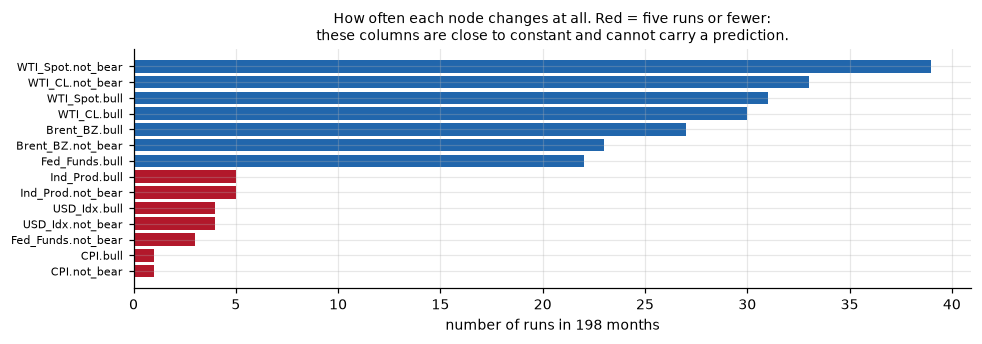

In [11]:
rs = pd.DataFrame({
    "node": B.columns,
    "runs_in_198_months": [1 + int((B[c].to_numpy()[1:] != B[c].to_numpy()[:-1]).sum())
                           for c in B.columns]}).sort_values("runs_in_198_months")
print(rs.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.2))
colour = ["#B2182B" if v <= 5 else "#2166AC" for v in rs["runs_in_198_months"]]
ax.barh(range(len(rs)), rs["runs_in_198_months"], color=colour)
ax.set_yticks(range(len(rs))); ax.set_yticklabels(rs["node"], fontsize=7)
ax.set_xlabel("number of runs in 198 months")
ax.set_title("How often each node changes at all. Red = five runs or fewer:\n"
             "these columns are close to constant and cannot carry a prediction.",
             fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(ROOT, "figures", "04_B3_run_counts.png"),
                                dpi=130, bbox_inches="tight")
plt.show()

## 7. What the look changes

**The panel is not seven series.** It is one crude-oil factor observed three ways,
plus one partially active rate node, plus four nodes that barely move. The
co-occurrence ordering in section 4b found this without being told: it placed the
three `not_bear` oil nodes adjacent and the three `bull` oil nodes adjacent,
because WTI_CL, Brent_BZ and WTI_Spot are the same underlying object.

**This is the shape behind Gate 1.0.** Phase 1 concluded that the panel carries no
predictive content for the one-month WTI regime beyond the regime's own
persistence, and reported that as an explanation of the source dissertation's
failure. The conclusion stands, and now it has a mechanism that can be *seen*:
the candidate parents either do not move, or they are crude oil under another
name. A search over parent sets was never going to find anything, and no scoring
rule, description length or gate catalogue could have rescued it.

**The support is thin.** Across all 364 node triples the median triple visits five
of the eight corners of its cube, and the modal corner holds about seven-tenths of
the rows. A gate is a labelling of all eight corners, so most of what distinguishes
one gate from another in the catalogue is being decided on corners the data never
visits. That is not a defect of the method; it is a statement about how much this
panel can identify, and it should have been known before any gate was fitted.

**What this does not say.** It says nothing about whether the method works. It says
this panel cannot test it. That is the distinction Phase 3 exists to act on: move
to daily data, where the oil series have texture at the scale the pivots live on,
and drop the macro covariates that are constant at monthly resolution rather than
carrying them along as decoration.